In [5]:
import pandas as pd

df = pd.read_csv('../../data/raw/youtoxic_english_1000.csv')

# Ver columnas disponibles
print(df.columns.tolist())
print(df.shape)
print(df.head(3))

# Detectar idioma de una muestra (instala langdetect si no está)
# pip install langdetect
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

# Columna de texto — ajusta el nombre según el CSV
col_texto = 'Text'  # o 'text', 'Comment', etc.

df['lang'] = df[col_texto].sample(500, random_state=42).apply(detect_lang)
print(df['lang'].value_counts())

['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']
(1000, 15)
              CommentId      VideoId  \
0  Ugg2KwwX0V8-aXgCoAEC  04kJtp6pVXI   
1  Ugg2s5AzSPioEXgCoAEC  04kJtp6pVXI   
2  Ugg3dWTOxryFfHgCoAEC  04kJtp6pVXI   

                                                Text  IsToxic  IsAbusive  \
0  If only people would just take a step back and...    False      False   
1  Law enforcement is not trained to shoot to app...     True       True   
2  \r\nDont you reckon them 'black lives matter' ...     True       True   

   IsThreat  IsProvocative  IsObscene  IsHatespeech  IsRacist  IsNationalist  \
0     False          False      False         False     False          False   
1     False          False      False         False     False          False   
2     False          False       True         False     False          False

In [6]:
print(df[['IsToxic', 'IsAbusive', 'IsHatespeech', 'IsRacist', 
          'IsSexist', 'IsHomophobic']].sum().sort_values(ascending=False))

print("\nBalanceo IsToxic:")
print(df['IsToxic'].value_counts(normalize=True).round(3))

IsToxic         462
IsAbusive       353
IsHatespeech    138
IsRacist        125
IsSexist          1
IsHomophobic      0
dtype: int64

Balanceo IsToxic:
IsToxic
False    0.538
True     0.462
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Longitud de comentarios
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print(df.groupby('IsToxic')[['text_length', 'word_count']].mean().round(1))


         text_length  word_count
IsToxic                         
False          182.7        33.1
True           189.9        34.6


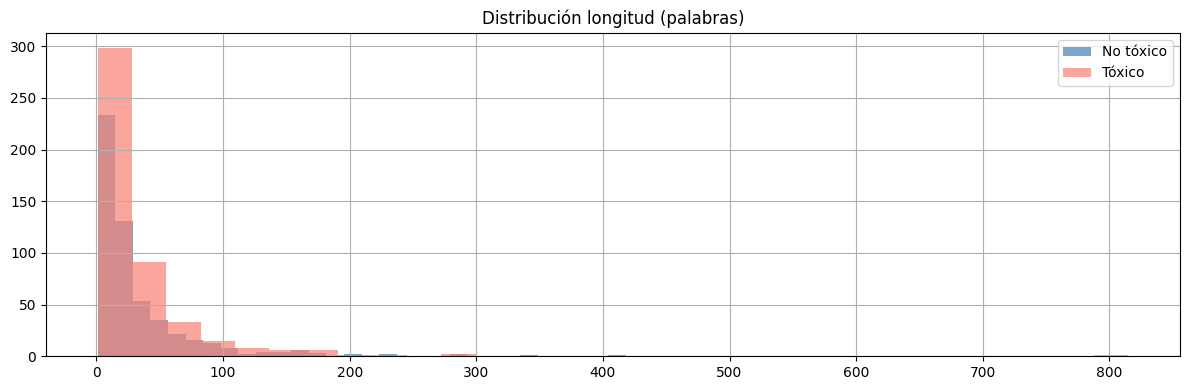

In [16]:
# 2. Distribución de longitud por clase
fig, ax = plt.subplots(figsize=(12, 4))
df[df['IsToxic']==False]['word_count'].hist(ax=ax, bins=30, alpha=0.7, label='No tóxico', color='steelblue')
df[df['IsToxic']==True]['word_count'].hist(ax=ax, bins=30, alpha=0.7, label='Tóxico', color='salmon')
ax.set_title('Distribución longitud (palabras)')
ax.legend()

plt.tight_layout()
plt.savefig('eda_longitud.png', dpi=150)
plt.show()


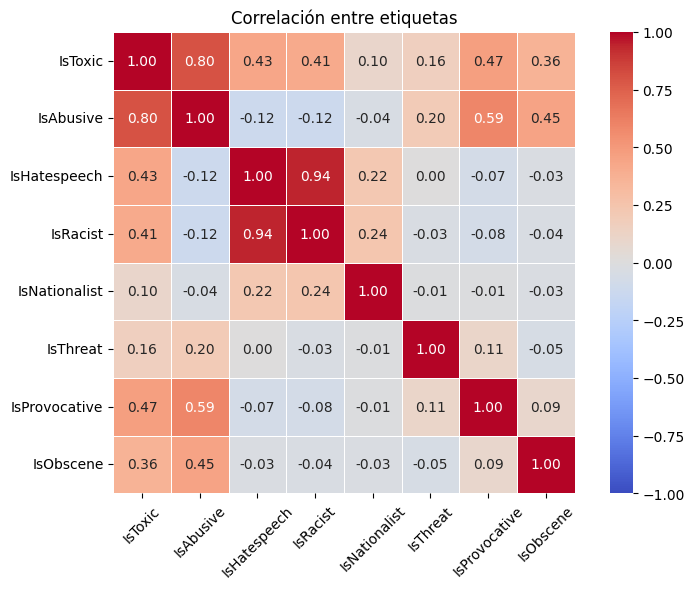

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

label_cols = ['IsToxic','IsAbusive','IsHatespeech','IsRacist',
            'IsNationalist','IsThreat','IsProvocative','IsObscene']

corr = df[label_cols].astype(int).corr()

sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)

ax.set_title('Correlación entre etiquetas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# 3. Correlación entre labels
label_cols = ['IsToxic','IsAbusive','IsHatespeech','IsRacist','IsNationalist','IsThreat','IsProvocative','IsObscene']
corr = df[label_cols].astype(int).corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1], cmap='coolwarm')
axes[1].set_title('Correlación entre etiquetas')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

In [11]:
# 4. Videos únicos y comentarios por video
print(f"\nVideos únicos: {df['VideoId'].nunique()}")
print(df['VideoId'].value_counts().head(5))

# 5. Comentarios vacíos o muy cortos
print(f"\nComentarios vacíos: {df['Text'].isna().sum()}")
print(f"Comentarios < 3 palabras: {(df['word_count'] < 3).sum()}")


Videos únicos: 13
VideoId
9pr1oE34bIM    274
04kJtp6pVXI    172
cT14IbTDW2c    146
dG7mZQvaQDk    112
TZxEyoplYbI    104
Name: count, dtype: int64

Comentarios vacíos: 0
Comentarios < 3 palabras: 34


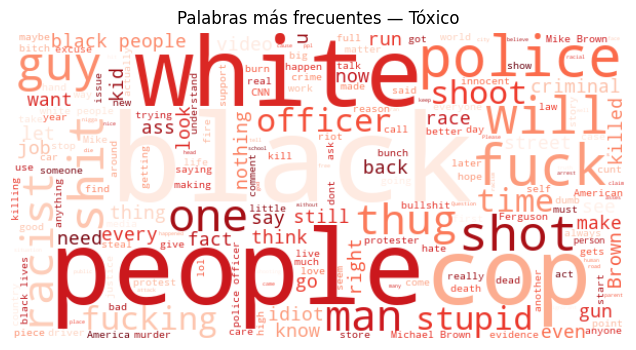

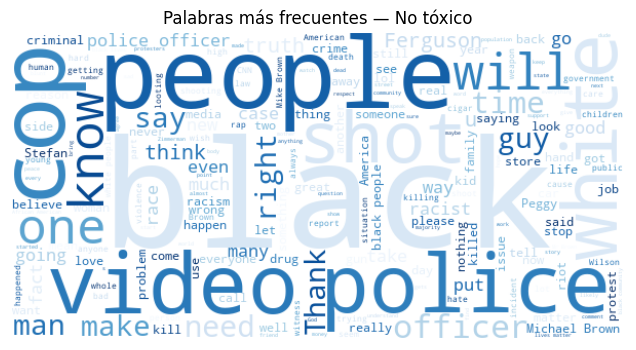

num_labels
0    538
2    108
3    288
4     46
5     16
6      4
Name: count, dtype: int64


In [19]:
# 1. Wordcloud — tóxico vs no tóxico (muy visual para la presentación)
from wordcloud import WordCloud

for label, color in [(True, 'Reds'), (False, 'Blues')]:
    texto = ' '.join(df[df['IsToxic']==label]['Text'].dropna())
    wc = WordCloud(width=600, height=300, background_color='white', colormap=color).generate(texto)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Palabras más frecuentes — {'Tóxico' if label else 'No tóxico'}")
    plt.savefig(f'wordcloud_{"toxico" if label else "notoxico"}.png', dpi=150)
    plt.show()

# 2. Cuántos comentarios tienen múltiples etiquetas activas
label_cols = ['IsToxic','IsAbusive','IsHatespeech','IsRacist',
            'IsNationalist','IsThreat','IsProvocative','IsObscene']
df['num_labels'] = df[label_cols].astype(int).sum(axis=1)
print(df['num_labels'].value_counts().sort_index())

In [20]:
def categorize(row):
    if not row['IsToxic']:
        return 'clean'
    elif row['IsHatespeech'] or row['IsRacist']:
        return 'hate'
    elif row['IsAbusive']:
        return 'abusive'
    else:
        return 'toxic_other'

df['label'] = df.apply(categorize, axis=1)
print(df['label'].value_counts())

label
clean      538
abusive    324
hate       138
Name: count, dtype: int64
